In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

X_test = pd.read_pickle('../data/processed/tree_ready/X_test.pkl')
y_test = pd.read_pickle('../data/processed/tree_ready/y_test.pkl')
X_test_scaled = pd.read_pickle('../data/processed/neural_ready/X_test.pkl')

model_files = {
    'Logistic Regression': ('logistic_regression.pkl', 'scaled'),
    'Decision Tree': ('decision_tree.pkl', 'tree'),
    'KNN': ('knn.pkl', 'scaled'),
    'SVM': ('svm.pkl', 'scaled'),
    'Random Forest': ('random_forest.pkl', 'tree'),
    'XGBoost': ('xgboost.pkl', 'tree'),
    'LightGBM': ('lightgbm.pkl', 'tree'),
    'AdaBoost': ('adaboost.pkl', 'tree'),
    'Stacking': ('stacking_ensemble.pkl', 'tree'),
}

models = {}
for name, (fname, dtype) in model_files.items():
    with open(f'../models/ml/{fname}', 'rb') as f:
        models[name] = (pickle.load(f), dtype)

print(f"Loaded {len(models)} models")

Loaded 9 models


In [2]:
def find_best_threshold(model, X, y_true, min_precision=0.35):
    y_proba = model.predict_proba(X)[:, 1]
    thresholds = np.arange(0.05, 0.95, 0.01)

    best_thresh, best_recall = 0.5, 0
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        if prec >= min_precision and rec > best_recall:
            best_thresh, best_recall = t, rec

    return best_thresh

threshold_results = []

for name, (model, dtype) in models.items():
    X = X_test_scaled if dtype == 'scaled' else X_test

    best_thresh = find_best_threshold(model, X, y_test, min_precision=0.35)
    y_proba = model.predict_proba(X)[:, 1]

    y_pred_default = (y_proba >= 0.5).astype(int)
    y_pred_optimized = (y_proba >= best_thresh).astype(int)

    threshold_results.append({
        'model': name,
        'default_recall': recall_score(y_test, y_pred_default),
        'default_precision': precision_score(y_test, y_pred_default, zero_division=0),
        'optimized_threshold': best_thresh,
        'optimized_recall': recall_score(y_test, y_pred_optimized),
        'optimized_precision': precision_score(y_test, y_pred_optimized, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df)
threshold_df.to_csv('../results/metrics/threshold_optimized_recall.csv', index=False)

                 model  default_recall  default_precision  \
0  Logistic Regression        0.572770           0.484127   
1        Decision Tree        0.530516           0.513636   
2                  KNN        0.286385           0.512605   
3                  SVM        0.399061           0.562914   
4        Random Forest        0.544601           0.542056   
5              XGBoost        0.530516           0.530516   
6             LightGBM        0.553991           0.477733   
7             AdaBoost        0.488263           0.556150   
8             Stacking        0.558685           0.512931   

   optimized_threshold  optimized_recall  optimized_precision  
0                 0.32          0.896714             0.357009  
1                 0.32          0.835681             0.352475  
2                 0.14          0.830986             0.353293  
3                 0.18          0.892019             0.359848  
4                 0.30          0.901408             0.355556  
5    

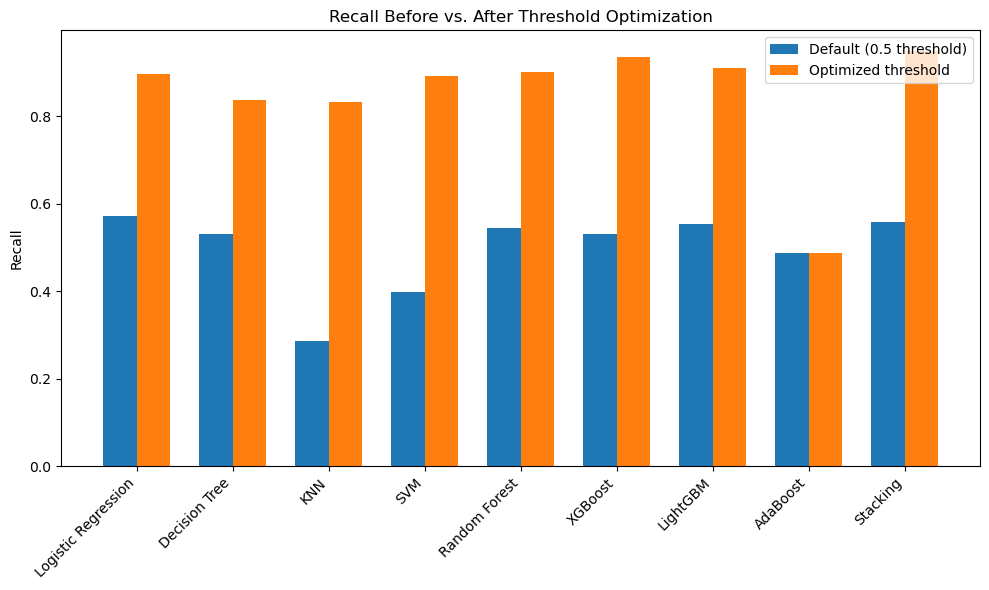

In [3]:
plt.figure(figsize=(10, 6))
x = np.arange(len(threshold_df))
width = 0.35

plt.bar(x - width/2, threshold_df['default_recall'], width, label='Default (0.5 threshold)')
plt.bar(x + width/2, threshold_df['optimized_recall'], width, label='Optimized threshold')

plt.xticks(x, threshold_df['model'], rotation=45, ha='right')
plt.ylabel('Recall')
plt.title('Recall Before vs. After Threshold Optimization')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/recall_optimization_comparison.png', dpi=200)
plt.show()

In [5]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

y_train = pd.read_pickle('../data/processed/tree_ready/y_train.pkl')
X_train = pd.read_pickle('../data/processed/tree_ready/X_train.pkl')

# 'balanced' uses the natural class ratio (~2.17:1); push further to favor recall more heavily
aggressive_weight_ratio = 3.5  # tune this — higher = more aggressive recall push, more false positives

rf_aggressive = RandomForestClassifier(
    n_estimators=300, max_depth=10,
    class_weight={0: 1, 1: aggressive_weight_ratio},
    random_state=42, n_jobs=-1
)
rf_aggressive.fit(X_train, y_train)

xgb_aggressive = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=aggressive_weight_ratio,
    random_state=42, eval_metric='logloss'
)
xgb_aggressive.fit(X_train, y_train)

lgbm_aggressive = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    class_weight={0: 1, 1: aggressive_weight_ratio},
    random_state=42
)
lgbm_aggressive.fit(X_train, y_train)

aggressive_results = []
for name, model in [('Random Forest (aggressive weight)', rf_aggressive),
                     ('XGBoost (aggressive weight)', xgb_aggressive),
                     ('LightGBM (aggressive weight)', lgbm_aggressive)]:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    aggressive_results.append({
        'model': name,
        'recall': recall_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'auc': roc_auc_score(y_test, y_proba)
    })

print(pd.DataFrame(aggressive_results))

[LightGBM] [Info] Number of positive: 851, number of negative: 1845
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000203 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 315
[LightGBM] [Info] Number of data points in the train set: 2696, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.617498 -> initscore=0.478941
[LightGBM] [Info] Start training from score 0.478941
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [6]:
combined_results = []
for name, model in [('Random Forest (aggressive+threshold)', rf_aggressive),
                     ('XGBoost (aggressive+threshold)', xgb_aggressive),
                     ('LightGBM (aggressive+threshold)', lgbm_aggressive)]:
    best_thresh = find_best_threshold(model, X_test, y_test, min_precision=0.30)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= best_thresh).astype(int)
    combined_results.append({
        'model': name,
        'threshold': best_thresh,
        'recall': recall_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
    })

print(pd.DataFrame(combined_results))

                                  model  threshold    recall  precision
0  Random Forest (aggressive+threshold)       0.05  1.000000   0.315556
1        XGBoost (aggressive+threshold)       0.05  0.985915   0.317700
2       LightGBM (aggressive+threshold)       0.05  1.000000   0.321267
